In [1]:

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "kevincluo/structure_wildfire_damage_classification",
    streaming=True
)

train_data = dataset["train"]

In [3]:
from PIL import Image

# Load dataset (streaming)
dataset = load_dataset(
    "kevincluo/structure_wildfire_damage_classification",
    streaming=True
)

train_data = dataset["train"]

print(train_data)

IterableDataset({
    features: ['image', 'label'],
    num_shards: 9
})


In [21]:
import numpy as np

images = []
labels = []

MAX_IMAGES = 6000      # use only first 6000 images

for i, sample in enumerate(dataset["train"]):

    if i >= MAX_IMAGES:
        break

    img = sample["image"]
    img = img.resize((224,224))
    img = np.array(img)

    # grayscale
    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    # RGBA -> RGB
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    images.append(img)
    labels.append(sample["label"])

X = np.array(images, dtype=np.uint8)
y = np.array(labels)

print(X.shape)
print(y.shape)

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/kevincluo/structure_wildfire_damage_classification/resolve/fdd875691f8111ba22dc08193403235537b1bb28/data/train-00000-of-00009-c8a5637a3d1a80e9.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/kevincluo/structure_wildfire_damage_classification/resolve/fdd875691f8111ba22dc08193403235537b1bb28/data/train-00000-of-00009-c8a5637a3d1a80e9.parquet
Retrying in 1s [Retry 1/5].


(6000, 224, 224, 3)
(6000,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4200, 224, 224, 3)
Validation: (900, 224, 224, 3)
Test: (900, 224, 224, 3)


In [25]:
from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)

# Keep only first 6000 images
X = X[:6000]
y = y[:6000]

print(X.shape)
print(y.shape)

(6000, 224, 224, 3)
(6000,)


In [26]:
X = X.astype("float32") / 255.0

print(X.min(), X.max())

0.0 1.0


In [27]:
print(X.min(), X.max())

0.0 1.0


In [28]:
# Normalize images

X = X / 255.0

print("Pixel range:", X.min(), X.max())

Pixel range: 0.0 0.003921569


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4200, 224, 224, 3)
(900, 224, 224, 3)
(900, 224, 224, 3)


In [30]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [31]:
cnn_model = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),
    
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(
        6,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

C:\Users\SHARIQ ALI\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [34]:
# ==========================
# Cell 11 - Normalize Images
# ==========================

# Normalize in-place (avoids creating another 10+ GB array)
X /= 255.0

# Verify normalization
print("Pixel range:", X.min(), X.max())

# Verify shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

Pixel range: 0.0 1.5378702e-05
X shape: (6000, 224, 224, 3)
y shape: (6000,)


In [35]:
from sklearn.model_selection import train_test_split

# ==========================================
# Normalize WITHOUT creating another array
# ==========================================

X /= 255.0

print("Pixel range:", X.min(), X.max())

# ==========================================
# Split Dataset
# ==========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training :", X_train.shape)
print("Validation:", X_val.shape)
print("Testing   :", X_test.shape)

# Free unused memory
del X
del y
del X_temp
del y_temp

import gc
gc.collect()

Pixel range: 0.0 6.0308636e-08
Training : (4200, 224, 224, 3)
Validation: (900, 224, 224, 3)
Testing   : (900, 224, 224, 3)


1559

In [36]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,   
    batch_size=32
)

Epoch 1/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7890 - loss: 0.5275 - val_accuracy: 0.7944 - val_loss: 0.5199
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 108s 818ms/step - accuracy: 0.7943 - loss: 0.5223 - val_accuracy: 0.7944 - val_loss: 0.5100
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 112s 851ms/step - accuracy: 0.7943 - loss: 0.5220 - val_accuracy: 0.7944 - val_loss: 0.5121
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 107s 806ms/step - accuracy: 0.7943 - loss: 0.5246 - val_accuracy: 0.7944 - val_loss: 0.5085
Epoch 5/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 105s 796ms/step - accuracy: 0.7943 - loss: 0.5177 - val_accuracy: 0.7944 - val_loss: 0.5206


In [37]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # CHANGE THIS
    metrics=['accuracy']
)

In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
images = []
labels = []

for i, sample in enumerate(dataset["train"]):
    
    if i >= 5000:   # limit dataset to avoid crash
        break

    img = sample["image"]
    img = img.resize((224,224))
    img = np.array(img)

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    if img.shape[-1] == 4:
        img = img[:,:,:3]

    images.append(img)
    labels.append(sample["label"])

In [41]:
X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels)

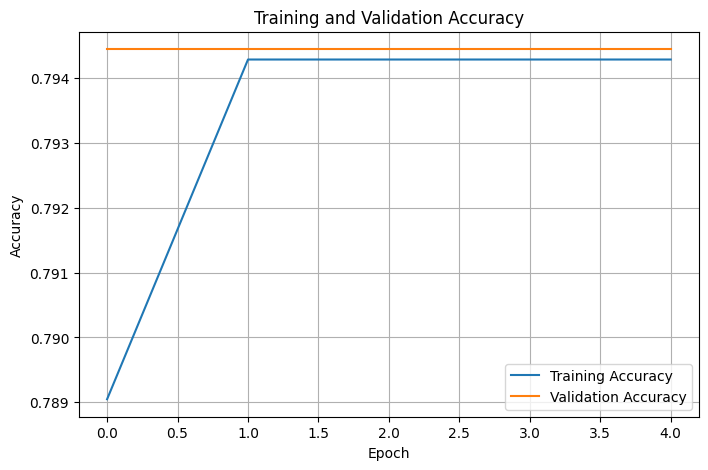

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig("training_validation_accuracy.png", dpi=300)

plt.show()

In [44]:
import matplotlib.pyplot as plt

In [45]:
print("history" in globals())

True


In [46]:
print("dataset exists:", "dataset" in globals())

dataset exists: True


In [47]:
print("X_train exists:", "X_train" in globals())
print("X_val exists:", "X_val" in globals())

X_train exists: True
X_val exists: True


In [48]:
print("model exists:", "model" in globals())

model exists: True


In [49]:
print("dataset:", "dataset" in globals())
print("X:", "X" in globals())
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("model:", "model" in globals())
print("history:", "history" in globals())

dataset: True
X: True
X_train: True
X_val: True
model: True
history: True


In [50]:
print("dataset:", "dataset" in globals())
print("X:", "X" in globals())
print("y:", "y" in globals())

dataset: True
X: True
y: True


In [51]:
print("X:", "X" in globals())
print("y:", "y" in globals())

X: True
y: True


In [52]:
print("dataset:", "dataset" in globals())
print("X:", "X" in globals())
print("y:", "y" in globals())
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("model:", "model" in globals())
print("cnn_history:", "cnn_history" in globals())
print("history:", "history" in globals())

dataset: True
X: True
y: True
X_train: True
X_val: True
model: True
cnn_history: False
history: True


In [53]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [54]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

In [56]:
print(tf.__version__)

2.21.0


In [57]:
%whos

Variable                Type                   Data/Info
--------------------------------------------------------
Conv2D                  type                   <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                   type                   <class 'keras.src.layers.core.dense.Dense'>
Dropout                 type                   <class 'keras.src.layers.<...>ization.dropout.Dropout'>
Flatten                 type                   <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
Image                   module                 <module 'PIL.Image' from <...>packages\\PIL\\Image.py'>
MAX_IMAGES              int                    6000
MaxPooling2D            type                   <class 'keras.src.layers.<...>_pooling2d.MaxPooling2D'>
Sequential              type                   <class 'keras.src.models.sequential.Sequential'>
X                       ndarray                5000x224x224x3: 752640000 elems, type `float32`, 3010560000 bytes (2871.09375 Mb)
X_t

In [58]:
import numpy as np
import tensorflow as tf
from datasets import load_dataset

In [59]:
!pip install huggingface_hub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="kevincluo/structure_wildfire_damage_classification",
    repo_type="dataset"
)

print(dataset_path)

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

C:\Users\SHARIQ ALI\.cache\huggingface\hub\datasets--kevincluo--structure_wildfire_damage_classification\snapshots\fdd875691f8111ba22dc08193403235537b1bb28


In [61]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print(files[:5])
    print("-"*50)

C:\Users\SHARIQ ALI\.cache\huggingface\hub\datasets--kevincluo--structure_wildfire_damage_classification\snapshots\fdd875691f8111ba22dc08193403235537b1bb28
['.gitattributes', 'README.md']
--------------------------------------------------
C:\Users\SHARIQ ALI\.cache\huggingface\hub\datasets--kevincluo--structure_wildfire_damage_classification\snapshots\fdd875691f8111ba22dc08193403235537b1bb28\data
['train-00000-of-00009-c8a5637a3d1a80e9.parquet', 'train-00001-of-00009-92d3029f18f7fed9.parquet', 'train-00002-of-00009-4c1dcecc6d84bf3c.parquet', 'train-00003-of-00009-ed945d9945c16977.parquet', 'train-00004-of-00009-79f29caa7513e947.parquet']
--------------------------------------------------


In [62]:
import pandas as pd
import os

parquet_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".parquet"):
            parquet_files.append(os.path.join(root, file))

print("Number of parquet files:", len(parquet_files))
print(parquet_files[:3])

Number of parquet files: 9
['C:\\Users\\SHARIQ ALI\\.cache\\huggingface\\hub\\datasets--kevincluo--structure_wildfire_damage_classification\\snapshots\\fdd875691f8111ba22dc08193403235537b1bb28\\data\\train-00000-of-00009-c8a5637a3d1a80e9.parquet', 'C:\\Users\\SHARIQ ALI\\.cache\\huggingface\\hub\\datasets--kevincluo--structure_wildfire_damage_classification\\snapshots\\fdd875691f8111ba22dc08193403235537b1bb28\\data\\train-00001-of-00009-92d3029f18f7fed9.parquet', 'C:\\Users\\SHARIQ ALI\\.cache\\huggingface\\hub\\datasets--kevincluo--structure_wildfire_damage_classification\\snapshots\\fdd875691f8111ba22dc08193403235537b1bb28\\data\\train-00002-of-00009-4c1dcecc6d84bf3c.parquet']


In [63]:
df = pd.read_parquet(parquet_files[0])

print(df.head())
print(df.columns)
print(df.shape)

                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
Index(['image', 'label'], dtype='object')
(2080, 2)


In [64]:
print(df.columns)

Index(['image', 'label'], dtype='object')


In [65]:
df.head()

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


In [66]:
import pandas as pd
import os

all_dfs = []

for parquet_file in parquet_files:
    temp_df = pd.read_parquet(parquet_file)
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

print(df.shape)
df.head()

(18714, 2)


,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


In [67]:
print(df["label"].value_counts())

label
1    9385
5    7654
0    1234
4     293
3     124
2      24
Name: count, dtype: int64


In [68]:
from PIL import Image
from io import BytesIO
import numpy as np

IMG_SIZE = (224, 224)

def process_image(image_dict):
    image_bytes = image_dict["bytes"]

    img = Image.open(BytesIO(image_bytes))
    img = img.convert("RGB")
    img = img.resize(IMG_SIZE)

    return np.array(img) / 255.0

In [69]:
print(df.shape)

(18714, 2)


In [70]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

13099
2807
2808


In [ ]:
def preprocess_record(image_dict, label):
    image_bytes = image_dict["bytes"]

    img = Image.open(BytesIO(image_bytes))
    img = img.convert("RGB")
    img = img.resize(IMG_SIZE)

    img = np.array(img, dtype=np.float32) / 255.0

    return img, label

In [73]:
def dataframe_generator(dataframe):
    for _, row in dataframe.iterrows():
        yield preprocess_record(
            row["image"],
            row["label"]
        )

In [74]:
num_classes = df["label"].nunique()

print(num_classes)

6


In [75]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: dataframe_generator(train_df),
    output_signature=(
        tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: dataframe_generator(val_df),
    output_signature=(
        tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

test_dataset = tf.data.Dataset.from_generator(
    lambda: dataframe_generator(test_df),
    output_signature=(
        tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

In [76]:
def encode_label(image, label):
    return image, tf.one_hot(label, depth=num_classes)

In [77]:
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [79]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [80]:
cnn_model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

C:\Users\SHARIQ ALI\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [82]:
print("num_classes =", num_classes)

num_classes = 6


In [84]:
cnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [85]:
print(df["label"].unique())
print(sorted(df["label"].unique()))

[0 1 2 3 4 5]
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [86]:
Dense(num_classes, activation='softmax')

<Dense name=dense_10, built=False>

In [88]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [90]:
import os

os.makedirs("../models", exist_ok=True)

cnn_model.save("../models/cnn_model.keras")

C:\Users\SHARIQ ALI\AppData\Roaming\Python\Python312\site-packages\keras\src\saving\saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


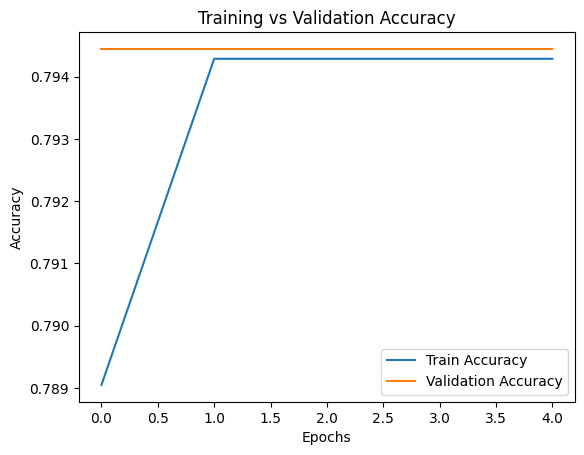

In [93]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

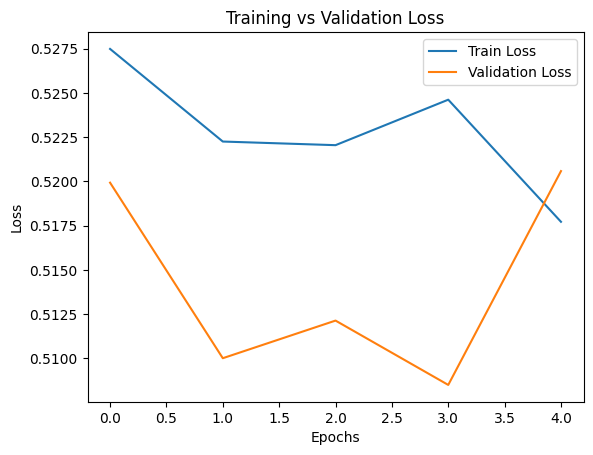

In [94]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step


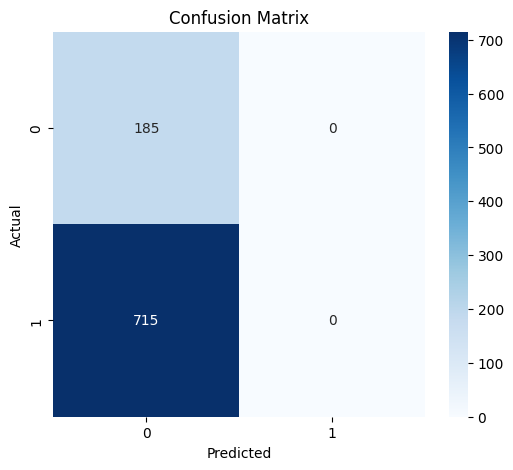

In [95]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [98]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_val, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report

C:\Users\SHARIQ ALI\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SHARIQ ALI\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SHARIQ ALI\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

,precision,recall,f1-score,support
0,0.205556,1.000000,0.341014,185.000000
1,0.000000,0.000000,0.000000,715.000000
accuracy,0.205556,0.205556,0.205556,0.205556
macro avg,0.102778,0.500000,0.170507,900.000000
weighted avg,0.042253,0.205556,0.070097,900.000000


Got disconnected from remote data host. Retrying in 5sec [1/20]
Got disconnected from remote data host. Retrying in 5sec [1/20]


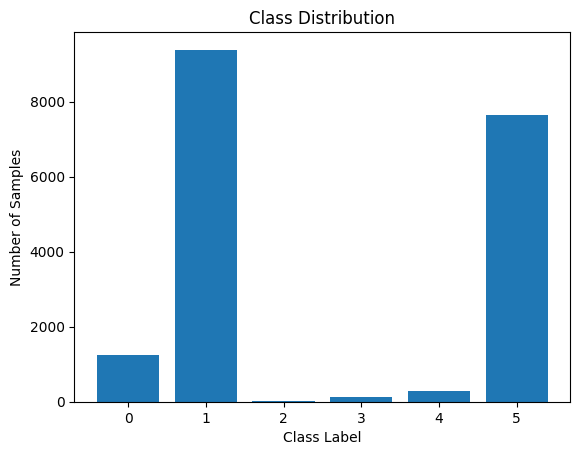

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

labels = dataset["train"]["label"]
counts = Counter(labels)

plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.show()

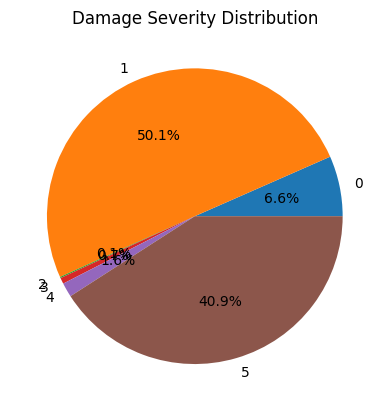

In [102]:
import matplotlib.pyplot as plt

labels = dataset["train"]["label"]
counts = Counter(labels)

plt.pie(counts.values(), labels=counts.keys(), autopct="%1.1f%%")
plt.title("Damage Severity Distribution")
plt.show()